# Lab 2.4 — SHAP Values & Model Interpretability
### Module 2 | AI/ML Intermediate Workshop — Nutanix Engineering

> **Kernel:** `aiml-venv`

---

**The black-box problem:**  
Your XGBoost model flags a Nutanix CVM as anomalous at 2am. The on-call SRE asks: *"Why is it flagging this server?"*  
If you can't answer, the team stops trusting the model — regardless of how good the PR-AUC is.

**SHAP (SHapley Additive exPlanations)** gives per-prediction explanations grounded in game theory.  
For every prediction, SHAP answers: *"How much did each feature contribute to this specific output?"*

**What you will build:**
- Global feature importance using SHAP summary plots
- Per-prediction waterfall explanations (the "why" for a single alert)
- Feature interaction analysis via dependence plots
- A comparison of SHAP vs built-in XGBoost importance
- A written model card for production handoff

> **Instructor Note:** Interpretability is not optional in production — regulators, SREs, and on-call engineers all need to understand model decisions. Push students to write every SHAP finding as a plain English sentence an SRE would understand at 3am.

## 📦 Requirements & Troubleshooting

### Required Packages

| Package | Install Name |
|---------|-------------|
| shap | `shap` |
| xgboost | `xgboost` |
| scikit-learn | `scikit-learn` |
| pandas | `pandas` |
| numpy | `numpy` |
| matplotlib | `matplotlib` |
| seaborn | `seaborn` |
| joblib | `joblib` |

**Install all at once:**
```bash
pip install shap xgboost scikit-learn pandas numpy matplotlib seaborn joblib
```

---

### ⚠️ Common Errors & Fixes

**`ModuleNotFoundError: No module named '...'`**
> Package is missing from the active Python environment.
> Fix: Run the pip install command above in a terminal, then **restart the kernel**.

**`CalledProcessError` — `--break-system-packages` / exit status 2**
> You are using a virtual environment (e.g. `myenv`) where that flag is not supported, or your pip version is old.
> Fix: Open a terminal, activate your venv (`source myenv/bin/activate`), then run `pip install <package>` without that flag.

**`Failed building wheel for <package>` / C extension errors**
> The package does not support your Python version (most common on Python 3.14).
> Fix: Switch the kernel to **Python 3.13**. Click the kernel name in the VS Code top-right corner → *Select Another Kernel* → *Python 3.13*. Then re-run.

**Packages install with no error but `ModuleNotFoundError` still appears**
> You installed into a different Python than the one the notebook is using.
> Fix: Check the kernel shown in the top-right of VS Code. Open a terminal, activate that environment, and install packages there.

**`PermissionError` or `[Errno 13]` when installing**
> Trying to install into a read-only system Python.
> Fix: Use a virtual environment — `python -m venv myenv && source myenv/bin/activate` — then install.


## Environment Check

In [1]:
import subprocess, sys

required = {
    'shap'      : 'shap',
    'xgboost'   : 'xgboost',
    'sklearn'   : 'scikit-learn',
    'pandas'    : 'pandas',
    'numpy'     : 'numpy',
    'matplotlib': 'matplotlib',
    'seaborn'   : 'seaborn',
    'joblib'    : 'joblib',
}
for pkg, inst in required.items():
    try:
        mod = __import__(pkg)
        print(f'  ✅ {pkg:<12} {getattr(mod, "__version__", "ok")}')
    except ImportError:
        print(f'  ⬇️  Installing {inst}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', inst, '--quiet'])
        print(f'  ✅ {pkg} installed')

  ⬇️  Installing shap...


You should consider upgrading via the '/Users/nikhil/AI:ML intermediate/myenv/bin/python -m pip install --upgrade pip' command.


  ✅ shap installed
  ⬇️  Installing xgboost...


You should consider upgrading via the '/Users/nikhil/AI:ML intermediate/myenv/bin/python -m pip install --upgrade pip' command.


  ✅ xgboost installed
  ✅ sklearn      1.6.1
  ✅ pandas       2.3.3
  ✅ numpy        2.0.2
  ✅ matplotlib   3.9.4
  ⬇️  Installing seaborn...
  ✅ seaborn installed
  ✅ joblib       1.5.3


You should consider upgrading via the '/Users/nikhil/AI:ML intermediate/myenv/bin/python -m pip install --upgrade pip' command.


## Imports

In [2]:
import warnings, os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import joblib
import shap

from sklearn.model_selection import train_test_split
from sklearn.metrics import average_precision_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import spearmanr
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
shap.initjs()
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('Imports OK ✅')

/Users/nikhil/AI:ML intermediate/myenv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports OK ✅


---
## Step 1: Load Data & Model

Load `features_engineered.csv` from Module 1 and the best model from Lab 2.2.  
If neither is available, we generate synthetic data and train a fresh model.

> **Instructor Note:** SHAP explanations are only meaningful for a well-performing model. Always verify PR-AUC before diving into explanations — explaining a bad model misleads more than it helps.

In [3]:
DATA_PATH  = os.path.join('..', 'Module_1', 'features_engineered.csv')
MODEL_PATH = 'best_tuned_model.pkl'

# ── Load data ─────────────────────────────────────────────────────────────────
try:
    df = pd.read_csv(DATA_PATH)
    DATA_SOURCE = 'Module 1 CSV'
except FileNotFoundError:
    np.random.seed(RANDOM_STATE)
    n = 800; cpu = np.random.uniform(5, 100, n)
    resp = np.clip(np.random.exponential(120, n), 1, 700)
    df = pd.DataFrame({
        'cpu_percent'          : cpu,
        'memory_mb'            : np.random.uniform(2048, 32768, n),
        'disk_io_mbps'         : np.clip(np.random.exponential(40, n), 0, 400),
        'response_time_ms'     : resp,
        'hour_of_day'          : np.random.randint(0, 24, n),
        'is_business_hours'    : np.random.randint(0, 2, n),
        'error_rate_per_host'  : np.random.poisson(2, n),
        'cpu_rolling_mean_5'   : cpu + np.random.normal(0, 3, n),
        'memory_rolling_mean_5': np.random.uniform(2048, 32768, n),
        'cpu_memory_ratio'     : cpu / 16,
        'io_per_cpu'           : np.random.exponential(1, n),
        'log_response_time'    : np.log1p(resp),
        'host_encoded'         : np.random.randint(0, 8, n),
        'loglevel_ERROR'       : np.random.randint(0, 2, n),
        'comp_Stargate'        : np.random.randint(0, 2, n),
        'comp_Cerebro'         : np.random.randint(0, 2, n),
        'is_high_cpu'          : (cpu > 80).astype(int),
        'is_slow_response'     : (resp > 500).astype(int),
    })
    DATA_SOURCE = 'Synthetic fallback'

df['is_anomaly'] = df['is_high_cpu'].astype(int)
DROP = [c for c in ['is_high_cpu', 'is_slow_response', 'message', 'date'] if c in df.columns]
df = df.drop(columns=DROP)
feature_cols = [c for c in df.columns if c != 'is_anomaly']
df[feature_cols] = df[feature_cols].apply(pd.to_numeric, errors='coerce').fillna(0)

X = df[feature_cols]
y = df['is_anomaly']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

# ── Load or train model ────────────────────────────────────────────────────────
try:
    model = joblib.load(MODEL_PATH)
    print('Loaded tuned model from Lab 2.2 ✅')
except FileNotFoundError:
    model = XGBClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        random_state=RANDOM_STATE, eval_metric='aucpr', verbosity=0)
    model.fit(X_train, y_train)
    print('Trained fresh model (run Lab 2.2 for tuned version)')

y_prob = model.predict_proba(X_test)[:, 1]
pr_auc = average_precision_score(y_test, y_prob)
print(f'\nData source  : {DATA_SOURCE}')
print(f'Dataset shape: {X.shape}  |  Anomaly rate: {y.mean():.1%}')
print(f'Test PR-AUC  : {pr_auc:.4f}  ← explain this model')

Loaded tuned model from Lab 2.2 ✅

Data source  : Module 1 CSV
Dataset shape: (460, 33)  |  Anomaly rate: 15.2%
Test PR-AUC  : 1.0000  ← explain this model


---
## Step 2: SHAP Fundamentals

**Core idea — Shapley values from cooperative game theory:**  
Imagine features as "players" in a game. The model output is the "payout."  
Each feature's Shapley value = its *average marginal contribution* across all possible feature orderings.

**For a single prediction:**
```
base_value  +  SHAP(feature_1)  +  SHAP(feature_2)  + ... +  SHAP(feature_n)  =  model_output
```

- SHAP value **> 0** → this feature *pushed the prediction higher* (toward anomaly)
- SHAP value **< 0** → this feature *pushed the prediction lower* (toward normal)
- The sum always adds up to the model output — this is the **additivity guarantee**

**TreeSHAP** (used for XGBoost/RF) computes exact Shapley values in polynomial time — no sampling or approximation needed. This is why SHAP works well for tree ensembles.

> **Instructor Note:** The additivity guarantee is what makes SHAP trustworthy — unlike other importance methods, you can verify it numerically. Show students the verification cell and let them check it themselves.

---
## Step 3: Compute SHAP Values

`shap.TreeExplainer` uses TreeSHAP — exact and fast for gradient boosted trees.  
We verify the additivity property: `base_value + sum(SHAP values) == model output`.

In [4]:
# Compute SHAP values
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
base_value  = explainer.expected_value

print(f'SHAP values shape : {shap_values.shape}  (samples × features)')
print(f'Base value        : {base_value:.4f}  (expected model log-odds)')
print(f'Features          : {X_test.shape[1]}')

# ── Verify additivity ─────────────────────────────────────────────────────────
import scipy.special
idx = 0
shap_sum       = shap_values[idx].sum() + base_value
model_logodds  = model.predict(X_test.iloc[[idx]], output_margin=True)[0]
model_prob     = model.predict_proba(X_test.iloc[[idx]])[0, 1]
shap_prob      = scipy.special.expit(shap_sum)

print(f'\n── Additivity check (sample 0) ─────────────────────────')
print(f'  Base value               : {base_value:.4f}')
print(f'  Sum of SHAP values       : {shap_values[idx].sum():.4f}')
print(f'  Base + SHAP sum          : {shap_sum:.4f}')
print(f'  Model log-odds output    : {model_logodds:.4f}')
print(f'  Match? {abs(shap_sum - model_logodds) < 1e-4} ✅')
print(f'\n  SHAP probability         : {shap_prob:.4f}')
print(f'  Model probability        : {model_prob:.4f}')

SHAP values shape : (92, 33)  (samples × features)
Base value        : -0.1155  (expected model log-odds)
Features          : 33

── Additivity check (sample 0) ─────────────────────────
  Base value               : -0.1155
  Sum of SHAP values       : -3.5245
  Base + SHAP sum          : -3.6400
  Model log-odds output    : -3.6400
  Match? True ✅

  SHAP probability         : 0.0256
  Model probability        : 0.0256


---
## Step 4: Global Feature Importance — Summary Plots

Two views of global SHAP importance:

1. **Bar plot** — mean absolute SHAP value per feature (how much on average each feature moves predictions)
2. **Beeswarm plot** — each dot = one sample; colour = feature value; x-position = SHAP impact

The beeswarm plot is more informative: it shows *direction* (which way the feature pushes) and *distribution* (does impact vary a lot or a little?).

> **Instructor Note:** Ask students: "A feature with high SHAP on the bar plot but tightly clustered dots on beeswarm — what does that mean?" Answer: high average impact but consistent direction (not conditional). A feature with wide spread = its impact depends heavily on its value.

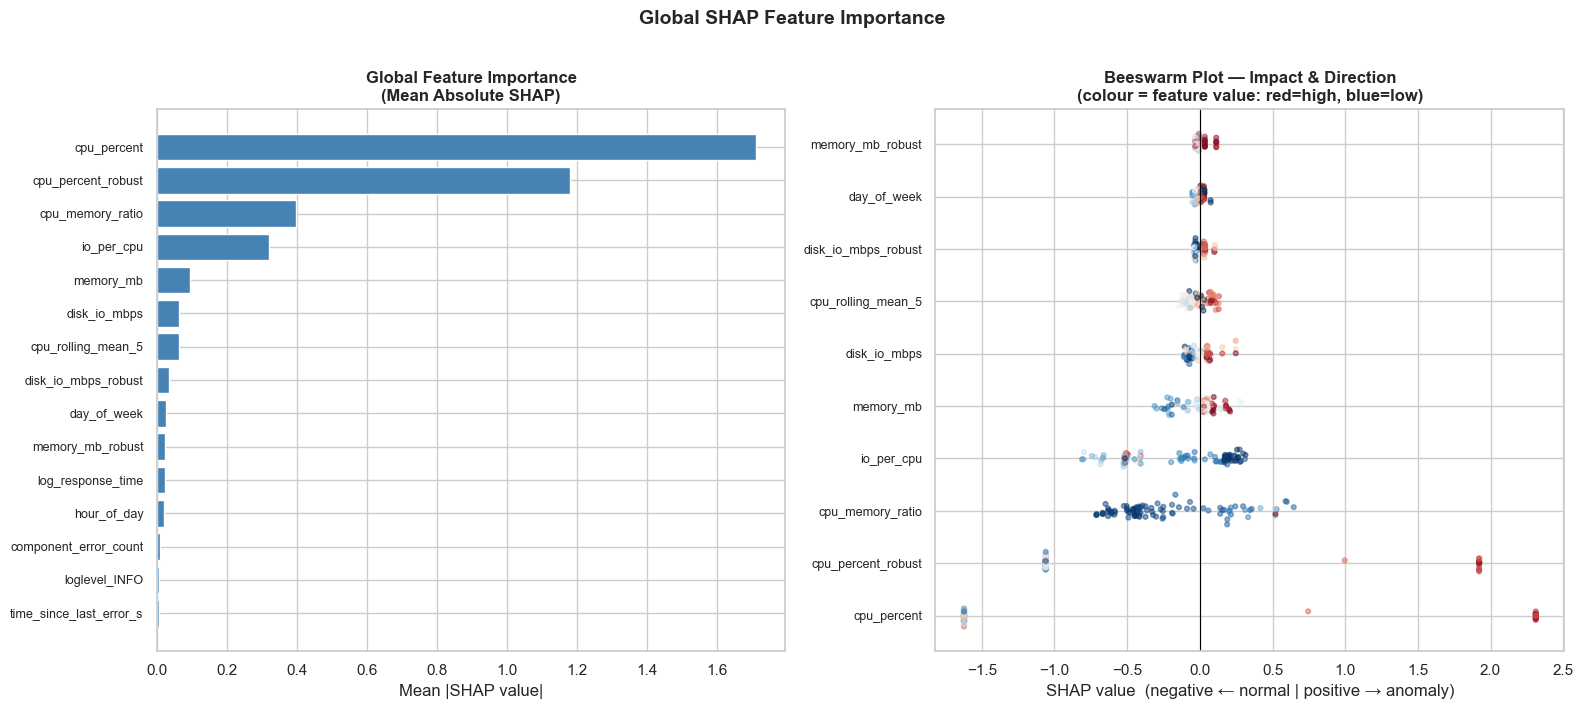

Top 5 features by mean |SHAP|:
  cpu_percent                    mean|SHAP|=1.7099  — generally pushes toward normal
  cpu_percent_robust             mean|SHAP|=1.1810  — generally pushes toward normal
  cpu_memory_ratio               mean|SHAP|=0.3975  — generally pushes toward normal
  io_per_cpu                     mean|SHAP|=0.3212  — generally pushes toward normal
  memory_mb                      mean|SHAP|=0.0952  — generally pushes toward anomaly


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── Bar plot ──────────────────────────────────────────────────────────────────
mean_abs_shap = np.abs(shap_values).mean(axis=0)
feat_shap = pd.Series(mean_abs_shap, index=X_test.columns).sort_values(ascending=True)
top15 = feat_shap.tail(15)

axes[0].barh(top15.index, top15.values, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Mean |SHAP value|')
axes[0].set_title('Global Feature Importance\n(Mean Absolute SHAP)', fontweight='bold')
axes[0].tick_params(axis='y', labelsize=9)

# ── Beeswarm (manual matplotlib version for portability) ─────────────────────
top10_feats = feat_shap.tail(10).index.tolist()
top10_idx   = [list(X_test.columns).index(f) for f in top10_feats]

shap_top  = shap_values[:, top10_idx]
feat_vals = X_test[top10_feats].values

for i, feat in enumerate(top10_feats[::-1]):
    fi  = len(top10_feats) - 1 - i
    sv  = shap_top[:, fi]
    fv  = feat_vals[:, fi]
    fv_norm = (fv - fv.min()) / (fv.max() - fv.min() + 1e-9)
    colors  = cm.RdBu_r(fv_norm)
    y_jitter = np.random.normal(i, 0.08, size=len(sv))
    axes[1].scatter(sv, y_jitter, c=colors, alpha=0.5, s=12)

axes[1].set_yticks(range(len(top10_feats)))
axes[1].set_yticklabels(top10_feats[::-1], fontsize=9)
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_xlabel('SHAP value  (negative ← normal | positive → anomaly)')
axes[1].set_title('Beeswarm Plot — Impact & Direction\n(colour = feature value: red=high, blue=low)',
                   fontweight='bold')

plt.suptitle('Global SHAP Feature Importance', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('shap_global_importance.png', dpi=120, bbox_inches='tight')
plt.show()

print('Top 5 features by mean |SHAP|:')
for feat, val in feat_shap.tail(5)[::-1].items():
    direction = 'pushes toward anomaly' if shap_values[:, list(X_test.columns).index(feat)].mean() > 0 else 'pushes toward normal'
    print(f'  {feat:<30} mean|SHAP|={val:.4f}  — generally {direction}')

---
## Step 5: Explaining a Single Prediction (Waterfall Plot)

Choose one **true positive** (real anomaly, correctly caught) and explain it.  
The waterfall plot shows how each feature's SHAP value moved the prediction from the base value to the final output.

This is the explanation you would give to an SRE when the model fires an alert.

> **Instructor Note:** Walk through reading the waterfall plot: start at base_value (the expected output across all samples), then each bar adds or subtracts. The final value is the model's output for this specific server. Ask: "What would you tell the on-call engineer based on this plot?" 

Explaining sample index 8
  Actual label      : 1 (ANOMALY)
  Predicted prob    : 0.9907
  Predicted label   : 1


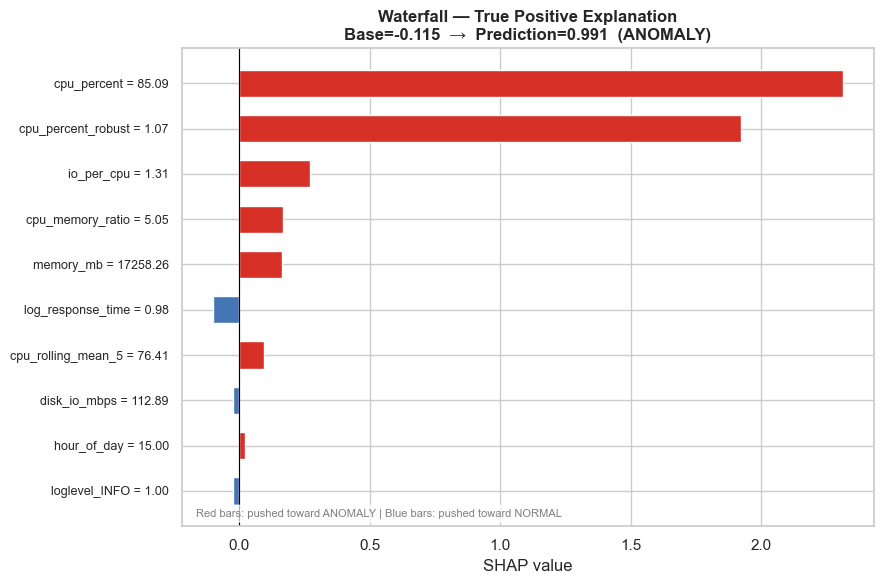


Plain English explanation for on-call SRE:
  "This server was flagged as anomalous (probability=99%).
   The main driver was cpu_percent = 85.09, which increased anomaly risk by 2.310.
   The main driver was cpu_percent_robust = 1.07, which increased anomaly risk by 1.921.
   The main driver was io_per_cpu = 1.31, which increased anomaly risk by 0.273.
   Starting from a baseline risk of -0.115."


In [6]:
# Find a true positive (actual anomaly, model caught it)
y_pred_test = (y_prob >= 0.5).astype(int)
tp_indices = np.where((y_test.values == 1) & (y_pred_test == 1))[0]
fn_indices = np.where((y_test.values == 1) & (y_pred_test == 0))[0]

if len(tp_indices) == 0:
    print('No true positives at threshold 0.5 — using highest probability anomaly sample')
    tp_indices = [np.argmax(y_prob)]

tp_idx = tp_indices[0]

print(f'Explaining sample index {tp_idx}')
print(f'  Actual label      : {y_test.iloc[tp_idx]} ({"ANOMALY" if y_test.iloc[tp_idx]==1 else "normal"})')
print(f'  Predicted prob    : {y_prob[tp_idx]:.4f}')
print(f'  Predicted label   : {y_pred_test[tp_idx]}')

# Manual waterfall plot
sv  = shap_values[tp_idx]
fv  = X_test.iloc[tp_idx]
top_n = 10
sorted_idx = np.argsort(np.abs(sv))[::-1][:top_n]
top_sv   = sv[sorted_idx]
top_feats = X_test.columns[sorted_idx]
top_fvals = fv.iloc[sorted_idx]

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#d73027' if v > 0 else '#4575b4' for v in top_sv]
y_pos  = range(len(top_sv))[::-1]
ax.barh(list(y_pos), top_sv, color=colors, edgecolor='white', height=0.6)
ax.axvline(0, color='black', lw=0.8)

labels = [str(f) + ' = ' + f'{v:.2f}' for f, v in zip(top_feats, top_fvals)]
ax.set_yticks(list(y_pos))
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel('SHAP value')
ax.set_title(f'Waterfall — True Positive Explanation\n'
             f'Base={base_value:.3f}  →  Prediction={y_prob[tp_idx]:.3f}  (ANOMALY)',
             fontweight='bold')

# Annotation
ax.text(0.02, 0.02,
        'Red bars: pushed toward ANOMALY | Blue bars: pushed toward NORMAL',
        transform=ax.transAxes, fontsize=8, color='grey',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

plt.tight_layout()
plt.savefig('shap_waterfall_tp.png', dpi=120, bbox_inches='tight')
plt.show()

# Plain English explanation
top_pos = [(f, v, fv[f]) for f, v in zip(top_feats, top_sv) if v > 0]
top_pos.sort(key=lambda x: -x[1])
print(f'\nPlain English explanation for on-call SRE:')
print(f'  "This server was flagged as anomalous (probability={y_prob[tp_idx]:.0%}).')
for feat, shap_v, feat_val in top_pos[:3]:
    print(f'   The main driver was {feat} = {feat_val:.2f}, which increased anomaly risk by {shap_v:.3f}.')
print(f'   Starting from a baseline risk of {base_value:.3f}."')

---
## Step 6: Explaining a Missed Failure (False Negative)

A false negative is the most dangerous model error — a real failure the model didn't catch.  
SHAP can tell you *why* the model missed it: which features made it look "normal."

This is how you debug the model and decide whether to:
1. Lower the threshold (catch more failures, more false alarms)
2. Add a new feature that distinguishes this type of failure
3. Retrain with more examples of this failure pattern

> **Instructor Note:** This analysis often reveals gaps in the training data — e.g., a specific component's failures look different from the majority. SHAP makes the gap visible.

Explaining sample index 67 — LOWEST-CONFIDENCE ANOMALY (proxy for missed failure)
  Actual label      : 1 (ANOMALY)
  Predicted prob    : 0.8519  ← model under-estimated risk


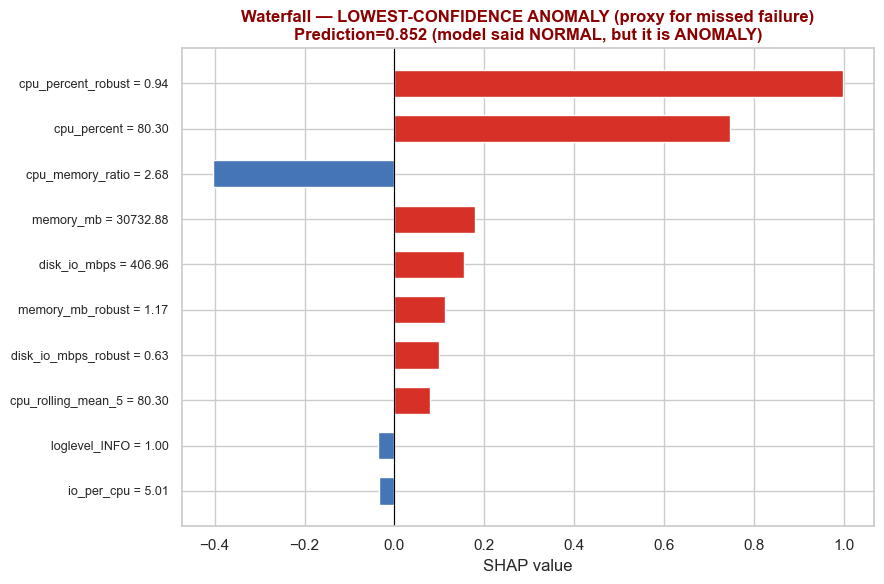


Why the model missed this failure:
  cpu_memory_ratio = 2.68 reduced anomaly score by 0.403
  loglevel_INFO = 1.00 reduced anomaly score by 0.037
  io_per_cpu = 5.01 reduced anomaly score by 0.035

Action: consider adding features that better capture this failure type,
or lower the decision threshold if missing this type is unacceptable.


In [7]:
if len(fn_indices) > 0:
    fn_idx = fn_indices[0]
    label = 'FALSE NEGATIVE (missed failure)'
else:
    # Use lowest-probability anomaly as proxy
    anomaly_indices = np.where(y_test.values == 1)[0]
    fn_idx = anomaly_indices[np.argmin(y_prob[anomaly_indices])]
    label = 'LOWEST-CONFIDENCE ANOMALY (proxy for missed failure)'

print(f'Explaining sample index {fn_idx} — {label}')
print(f'  Actual label      : {y_test.iloc[fn_idx]} (ANOMALY)')
print(f'  Predicted prob    : {y_prob[fn_idx]:.4f}  ← model under-estimated risk')

sv_fn   = shap_values[fn_idx]
fv_fn   = X_test.iloc[fn_idx]
sorted_fn = np.argsort(np.abs(sv_fn))[::-1][:10]

fig, ax = plt.subplots(figsize=(9, 6))
colors_fn = ['#d73027' if v > 0 else '#4575b4' for v in sv_fn[sorted_fn]]
y_pos_fn  = range(len(sorted_fn))[::-1]
ax.barh(list(y_pos_fn), sv_fn[sorted_fn], color=colors_fn, edgecolor='white', height=0.6)
ax.axvline(0, color='black', lw=0.8)
labels_fn = [str(feat) + ' = ' + f'{val:.2f}' for feat, val in zip(X_test.columns[sorted_fn], fv_fn.iloc[sorted_fn])]
ax.set_yticks(list(y_pos_fn)); ax.set_yticklabels(labels_fn, fontsize=9)
ax.set_xlabel('SHAP value')
ax.set_title(f'Waterfall — {label}\n'
             f'Prediction={y_prob[fn_idx]:.3f} (model said NORMAL, but it is ANOMALY)',
             fontweight='bold', color='darkred')
plt.tight_layout()
plt.savefig('shap_waterfall_fn.png', dpi=120, bbox_inches='tight')
plt.show()

# Identify what made it look normal
neg_shap = [(X_test.columns[i], sv_fn[i], fv_fn.iloc[i])
            for i in sorted_fn if sv_fn[i] < 0]
print(f'\nWhy the model missed this failure:')
for feat, shap_v, feat_val in neg_shap[:3]:
    print(f'  {feat} = {feat_val:.2f} reduced anomaly score by {abs(shap_v):.3f}')
print(f'\nAction: consider adding features that better capture this failure type,')
print(f'or lower the decision threshold if missing this type is unacceptable.')

---
## Step 7: SHAP Dependence Plots — Feature Interactions

A dependence plot shows how a feature's SHAP value changes as its raw value increases.  
The colour shows the **interacting feature** — a pattern in colour reveals an interaction effect.

Example: "CPU's SHAP value is high only when memory is also high" → CPU × memory interaction.

> **Instructor Note:** Dependence plots often reveal non-linear effects and interaction terms that are invisible in the global importance bar chart. These insights directly inform feature engineering decisions.

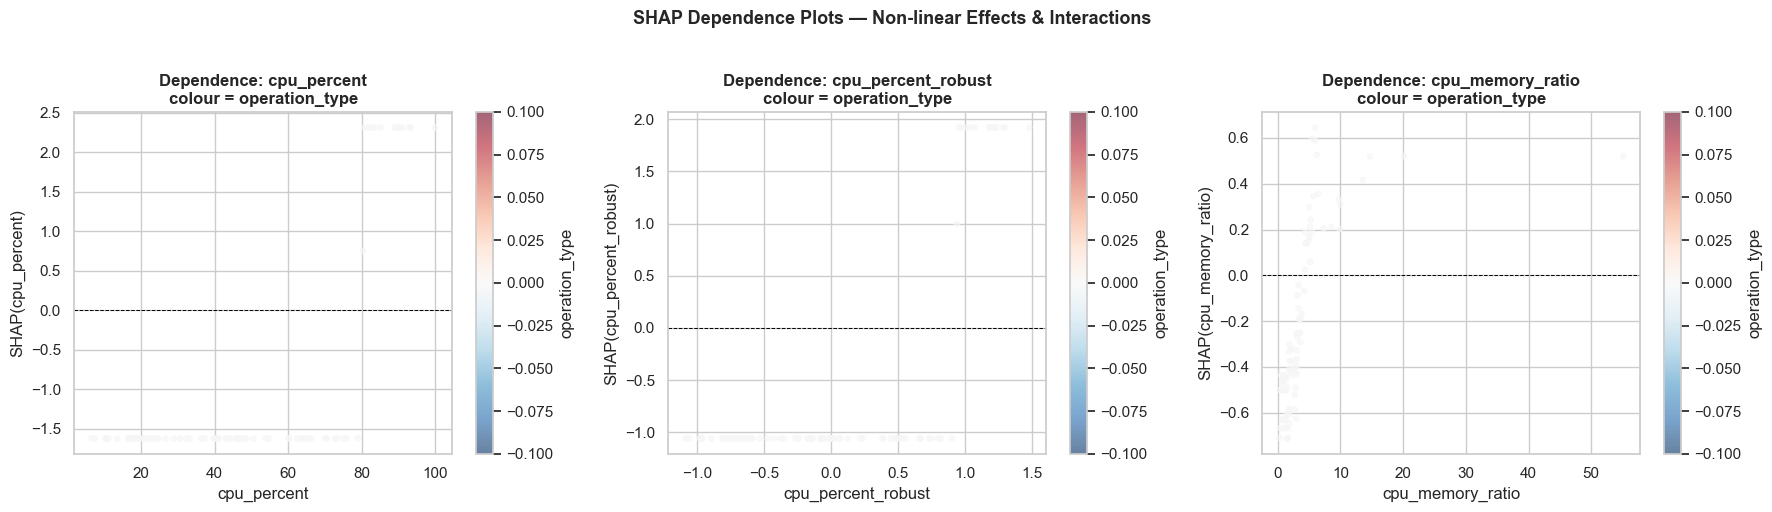

What to look for in dependence plots:
  Curved SHAP line → non-linear relationship
  Colour gradient splitting the plot → interaction effect
  Flat line → feature has consistent but threshold-independent impact


In [8]:
top3_feats = feat_shap.tail(3).index.tolist()[::-1]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, feat in zip(axes, top3_feats):
    feat_idx = list(X_test.columns).index(feat)
    sv_feat  = shap_values[:, feat_idx]
    fv_feat  = X_test[feat].values

    # Auto-select interaction feature (highest |correlation| with SHAP residual)
    residual = sv_feat - np.polyval(np.polyfit(fv_feat, sv_feat, 1), fv_feat)
    corrs = [abs(np.corrcoef(residual, X_test.iloc[:, j].values)[0, 1])
             for j in range(X_test.shape[1]) if j != feat_idx]
    interact_feat = X_test.columns[[j for j in range(X_test.shape[1]) if j != feat_idx][np.argmax(corrs)]]
    interact_vals = X_test[interact_feat].values
    interact_norm = (interact_vals - interact_vals.min()) / (interact_vals.max() - interact_vals.min() + 1e-9)

    sc = ax.scatter(fv_feat, sv_feat, c=interact_norm, cmap='RdBu_r', alpha=0.6, s=15)
    plt.colorbar(sc, ax=ax, label=interact_feat[:20])
    ax.axhline(0, color='black', lw=0.7, linestyle='--')
    ax.set_xlabel(feat); ax.set_ylabel(f'SHAP({feat})')
    ax.set_title(f'Dependence: {feat}\ncolour = {interact_feat[:20]}', fontweight='bold')

plt.suptitle('SHAP Dependence Plots — Non-linear Effects & Interactions',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('shap_dependence.png', dpi=120, bbox_inches='tight')
plt.show()

print('What to look for in dependence plots:')
print('  Curved SHAP line → non-linear relationship')
print('  Colour gradient splitting the plot → interaction effect')
print('  Flat line → feature has consistent but threshold-independent impact')

---
## Step 8: SHAP vs Built-in Feature Importance

XGBoost's built-in `feature_importances_` (gain) and SHAP `mean |SHAP|` both rank features — but they can disagree significantly.

**Why they differ:**
- Built-in gain: total improvement in loss function from splits on that feature, across all trees
- SHAP: average marginal contribution to predictions, accounting for feature correlations

**When they disagree:** The built-in importance may over-rank features that are highly correlated with others (they share credit) or that are used in many trees but with small individual impact. SHAP is more reliable.

> **Instructor Note:** Spearman rank correlation between the two rankings is the key number. Below 0.8 → significant disagreement → investigate which features are misleading the built-in method.

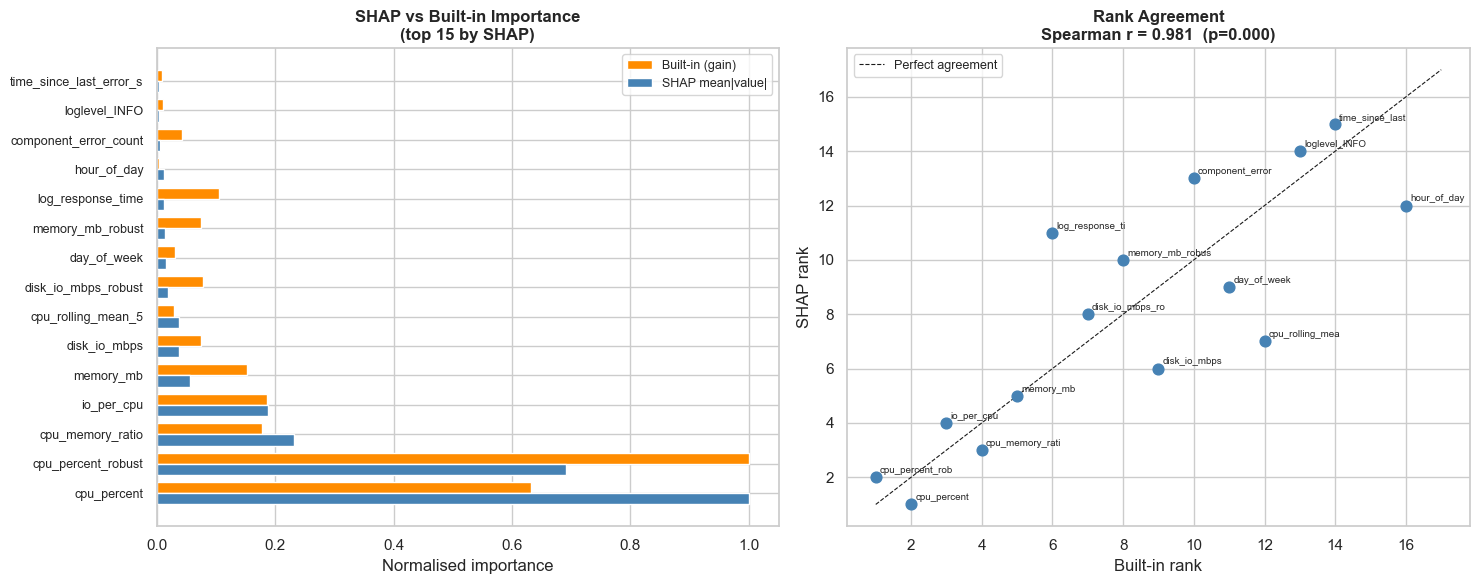

Spearman rank correlation: 0.981
  > 0.9 → strong agreement
  0.7–0.9 → moderate agreement (check disagreeing features)
  < 0.7 → significant disagreement — trust SHAP over built-in

Features with large rank disagreement (>3 positions):
  cpu_rolling_mean_5             built-in rank=12  SHAP rank=7  delta=5
  log_response_time              built-in rank=6  SHAP rank=11  delta=5
  hour_of_day                    built-in rank=16  SHAP rank=12  delta=4


In [9]:
# Built-in XGBoost gain importance
builtin_imp = pd.Series(model.feature_importances_, index=X_test.columns)
shap_imp    = pd.Series(np.abs(shap_values).mean(axis=0), index=X_test.columns)

# Align and compare top 15
top15_feats = shap_imp.nlargest(15).index
builtin_top = builtin_imp[top15_feats]
shap_top15  = shap_imp[top15_feats]

# Rank correlation
spearman_r, p_val = spearmanr(
    builtin_imp.rank(ascending=False),
    shap_imp.rank(ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Side by side bar charts
x = np.arange(len(top15_feats))
w = 0.38
axes[0].barh(x + w/2, builtin_top.values / builtin_top.max(), w,
             label='Built-in (gain)', color='darkorange', edgecolor='white')
axes[0].barh(x - w/2, shap_top15.values / shap_top15.max(),  w,
             label='SHAP mean|value|', color='steelblue', edgecolor='white')
axes[0].set_yticks(x)
axes[0].set_yticklabels(top15_feats, fontsize=9)
axes[0].set_xlabel('Normalised importance')
axes[0].set_title('SHAP vs Built-in Importance\n(top 15 by SHAP)', fontweight='bold')
axes[0].legend(fontsize=9)

# Rank scatter
rank_builtin = builtin_imp.rank(ascending=False)
rank_shap    = shap_imp.rank(ascending=False)
common = top15_feats
axes[1].scatter(rank_builtin[common], rank_shap[common], color='steelblue', s=60, zorder=3)
for feat in common:
    axes[1].annotate(feat[:15], (rank_builtin[feat], rank_shap[feat]),
                     fontsize=7, xytext=(3,3), textcoords='offset points')
lim = max(rank_builtin[common].max(), rank_shap[common].max()) + 1
axes[1].plot([1, lim], [1, lim], 'k--', lw=0.8, label='Perfect agreement')
axes[1].set_xlabel('Built-in rank'); axes[1].set_ylabel('SHAP rank')
axes[1].set_title(f'Rank Agreement\nSpearman r = {spearman_r:.3f}  (p={p_val:.3f})',
                   fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('shap_vs_builtin.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'Spearman rank correlation: {spearman_r:.3f}')
print(f'  > 0.9 → strong agreement')
print(f'  0.7–0.9 → moderate agreement (check disagreeing features)')
print(f'  < 0.7 → significant disagreement — trust SHAP over built-in')

disagree = [(f, int(rank_builtin[f]), int(rank_shap[f]))
            for f in common if abs(rank_builtin[f] - rank_shap[f]) > 3]
if disagree:
    print(f'\nFeatures with large rank disagreement (>3 positions):')
    for feat, rb, rs in sorted(disagree, key=lambda x: abs(x[1]-x[2]), reverse=True):
        print(f'  {feat:<30} built-in rank={rb}  SHAP rank={rs}  delta={abs(rb-rs)}')

---
## Step 9: Write a Model Card

A model card is a short document that ships with every production model.  
It answers: what does this model do, how well, on what data, with what known limitations?

**Fill in the sections marked `FILL_IN` based on your SHAP analysis above.**

> **Instructor Note:** Model cards are now standard practice at major ML teams (Google, Meta, Anthropic). They protect teams legally and help on-call engineers understand model behaviour without reading the code.

In [10]:
import datetime

model_card = {
    "model_name"       : "Nutanix CVM Anomaly Detector",
    "version"          : "1.0",
    "model_type"       : type(model).__name__,
    "trained_at"       : datetime.datetime.utcnow().strftime('%Y-%m-%d'),
    "intended_use"     : "Flag Nutanix Controller VMs with anomalous CPU behaviour for ops review",
    "not_intended_for" : "Autonomous remediation without human review",

    "training_data": {
        "source"       : DATA_SOURCE,
        "n_samples"    : int(len(X)),
        "anomaly_rate" : f'{y.mean():.1%}',
        "features"     : int(X.shape[1]),
    },

    "performance": {
        "metric"       : "PR-AUC (preferred for imbalanced classes)",
        "test_pr_auc"  : round(average_precision_score(y_test, y_prob), 4),
        "test_f1"      : round(f1_score(y_test, (y_prob>=0.5).astype(int), zero_division=0), 4),
        "threshold"    : 0.5,
        "note"         : "Adjust threshold based on ops alert volume constraints (see Lab 2.3)",
    },

    "top_5_features_by_shap": list(feat_shap.tail(5).index[::-1]),

    "known_limitations": [
        "FILL_IN — based on your false negative analysis in Step 6",
        "FILL_IN — based on your dependence plot analysis in Step 7",
        "Model trained on synthetic/Module 1 data — retrain on live Nutanix telemetry before production",
    ],

    "bias_warnings": [
        "FILL_IN — does SHAP show any host- or component-specific bias?",
    ],

    "recommended_retraining": "Monthly, or when PR-AUC on live data drops > 0.05 from baseline",
}

with open('model_card.json', 'w') as f:
    json.dump(model_card, f, indent=2)

print(json.dumps(model_card, indent=2))
print('\nSaved: model_card.json')

{
  "model_name": "Nutanix CVM Anomaly Detector",
  "version": "1.0",
  "model_type": "XGBClassifier",
  "trained_at": "2026-05-30",
  "intended_use": "Flag Nutanix Controller VMs with anomalous CPU behaviour for ops review",
  "not_intended_for": "Autonomous remediation without human review",
  "training_data": {
    "source": "Module 1 CSV",
    "n_samples": 460,
    "anomaly_rate": "15.2%",
    "features": 33
  },
  "performance": {
    "metric": "PR-AUC (preferred for imbalanced classes)",
    "test_pr_auc": 1.0,
    "test_f1": 1.0,
    "threshold": 0.5,
    "note": "Adjust threshold based on ops alert volume constraints (see Lab 2.3)"
  },
  "top_5_features_by_shap": [
    "cpu_percent",
    "cpu_percent_robust",
    "cpu_memory_ratio",
    "io_per_cpu",
    "memory_mb"
  ],
  "known_limitations": [
    "FILL_IN \u2014 based on your false negative analysis in Step 6",
    "FILL_IN \u2014 based on your dependence plot analysis in Step 7",
    "Model trained on synthetic/Module 1 da

---
## Checkpoint — Discussion Questions

1. **The additivity guarantee says base_value + Σ(SHAP) = model output. Why is this property important for debugging model errors?**
2. **Your beeswarm plot shows `cpu_percent` with red dots (high value) concentrated on the right (positive SHAP). What does this tell you about how the model uses CPU information?**
3. **Spearman correlation between SHAP and built-in importance is 0.72. You need to explain to an SRE which features drive alerts. Which ranking do you show them, and why?**
4. **The false negative analysis shows the missed server had low `cpu_percent` but high `error_rate_per_host`. What does this suggest about improving the model?**

---
## Key Takeaways

| Concept | What You Did |
|---|---|
| SHAP fundamentals | Verified additivity; understood base value + SHAP = output |
| Global importance | Summary bar + beeswarm plot — direction and magnitude |
| Local explanation | Waterfall plots for true positive and false negative |
| Feature interactions | Dependence plots revealing non-linear effects |
| Reliability | Compared SHAP vs built-in importance; used Spearman correlation |
| Production handoff | Wrote a model card with performance, limitations, bias warnings |

**Module 2 Complete ✅**

**Next:** Module 3 — Bridging ML and Engineering: Model Deployment with FastAPI & Docker

---
## 🎯 Assignment — Challenges

### Challenge 1 — SHAP for a Specific Component

Split the test set into rows where `comp_Stargate == 1` and `comp_Cerebro == 1`.

**Tasks:**
1. Compute mean SHAP values separately for each component cohort
2. Plot side-by-side bar charts of top-10 features per cohort
3. Identify: do Stargate and Cerebro anomalies have different "signatures" in SHAP space?
4. Calculate Spearman correlation between the two cohorts' SHAP rankings
5. Answer: Should you train separate anomaly detectors per component? What is the trade-off?

*Note: If using synthetic data, substitute any two binary component columns*

In [11]:
# Challenge 1 — Your solution here



### Challenge 2 — SHAP for Random Forest

Train a `RandomForestClassifier(n_estimators=200, random_state=42)` on the same data.  
Compute SHAP values using `shap.TreeExplainer`.

**Tasks:**
1. Plot the global SHAP importance bar chart for RF (top 15 features)
2. Overlay XGBoost and RF SHAP rankings on the same chart (grouped bars)
3. Calculate Spearman rank correlation between RF-SHAP and XGBoost-SHAP rankings
4. For any feature where the models strongly disagree (rank difference > 4), investigate:
   - What is the feature's correlation with the target?
   - Does one model seem to be capturing a spurious pattern?
5. Answer: If you had to deploy one model for explainability to a non-technical stakeholder, which would you choose and why?

In [12]:
# Challenge 2 — Your solution here



### Challenge 3 — SHAP-Based Feature Selection

SHAP can guide feature selection: remove features with consistently near-zero SHAP values.

**Tasks:**
1. Identify all features where `mean |SHAP| < 0.01` (low global impact)
2. Retrain XGBoost on the dataset with those features removed
3. Compare: PR-AUC before and after feature removal (use 5-fold CV)
4. Plot: number of features removed vs CV PR-AUC (a feature selection curve)
5. Find the minimum number of features that keeps CV PR-AUC within 0.02 of the full-feature model
6. Answer: Why might removing low-SHAP features *improve* model performance in some cases?

*Hint: Think about overfitting, noise features, and the bias-variance trade-off*

In [13]:
# Challenge 3 — Your solution here

